In [1]:
import os
import re
import glob
import pandas as pd
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import pyslha
import xml.etree.ElementTree as ET
import pyslha
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

cm = plt.colormaps['RdYlBu']


In [2]:
pd.read_pickle('../ma5Results_scalar_all.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.211444,0.002289
1,IM1,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.177396,0.001992
2,IM2,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.140901,0.001661
3,IM3,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.109688,0.001336
4,IM4,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.084982,0.001098
...,...,...,...,...,...,...,...,...,...
1035,EM8,2.655520,2.829443,4.888432e-02,dms_1_750,1,1.0,0.000337,0.000009
1036,EM9,2.919149,2.630575,4.888432e-02,dms_1_750,1,1.0,0.000154,0.000006
1037,EM10,5.581551,11.618738,4.888432e-02,dms_1_750,1,1.0,0.000072,0.000003
1038,EM11,5.841690,6.421301,4.888432e-02,dms_1_750,1,1.0,0.000038,0.000002


In [3]:
pd.read_pickle('../ma5Results_scalar_all_add.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,17.601130,17.608879,0.015506,dms_100_10,1,100.0,0.045542,0.000666
1,IM1,10.721137,10.733256,0.015506,dms_100_10,1,100.0,0.029423,0.000528
2,IM2,10.082023,10.109077,0.015506,dms_100_10,1,100.0,0.017691,0.000360
3,IM3,9.455234,9.513033,0.015506,dms_100_10,1,100.0,0.010400,0.000204
4,IM4,10.557332,10.673288,0.015506,dms_100_10,1,100.0,0.005942,0.000087
...,...,...,...,...,...,...,...,...,...
203,EM8,0.912056,0.981217,0.000021,dms_1_3000,1,1.0,0.000988,0.000031
204,EM9,0.721554,0.650229,0.000021,dms_1_3000,1,1.0,0.000627,0.000023
205,EM10,1.148467,2.500588,0.000021,dms_1_3000,1,1.0,0.000359,0.000014
206,EM11,0.988206,1.097167,0.000021,dms_1_3000,1,1.0,0.000228,0.000012


In [4]:
pd.read_pickle('../ma5Results_scalar_all_add2.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,-1.000000,-1.000000,4.415982e-08,dms_1000_10,1,1000.0,0.216437,0.002358
1,IM1,-1.000000,-1.000000,4.415982e-08,dms_1000_10,1,1000.0,0.180759,0.002070
2,IM2,-1.000000,-1.000000,4.415982e-08,dms_1000_10,1,1000.0,0.145582,0.001745
3,IM3,-1.000000,-1.000000,4.415982e-08,dms_1000_10,1,1000.0,0.115690,0.001461
4,IM4,-1.000000,-1.000000,4.415982e-08,dms_1000_10,1,1000.0,0.091414,0.001198
...,...,...,...,...,...,...,...,...,...
2153,EM8,0.300309,0.323082,4.583715e-06,dms_600_750,1,600.0,0.002996,0.000203
2154,EM9,0.267892,0.241411,4.583715e-06,dms_600_750,1,600.0,0.001670,0.000099
2155,EM10,0.391433,-1.000000,4.583715e-06,dms_600_750,1,600.0,0.001044,0.000129
2156,EM11,0.423472,0.470163,4.583715e-06,dms_600_750,1,600.0,0.000530,0.000031


In [5]:
# pd.read_pickle('../ma5Results_vector_all.pcl')

In [6]:
2054/26

79.0

In [7]:
df_s1 = pd.read_pickle('../ma5Results_scalar_all.pcl')
df_s2 = pd.read_pickle('../ma5Results_scalar_all_add.pcl')
df_s3 = pd.read_pickle('../ma5Results_scalar_all_add2.pcl')
df_s4 = pd.read_pickle('../ma5_test_spin0_scalar_match_add/ma5Results_scalar_add.pcl')
dfs_s = [df_s1, df_s2, df_s3, df_s4]

df_s = pd.concat(dfs_s, ignore_index=True)
# df_s = pd.read_pickle('../ma5_test_spin0_scalar_match_add/ma5Results_scalar_add.pcl')
df_p1 = pd.read_pickle('../ma5Results_pseudo_all.pcl')
df_p2 = pd.read_pickle('../ma5_test_spin0_pseudo_match_add/ma5Results_pseudo_add.pcl')
dfs_p = [df_p1, df_p2]
df_p = pd.concat(dfs_p, ignore_index=True)
# df_p = pd.read_pickle('../ma5Results_pseudo_all.pcl')
# df_p = pd.read_pickle('../ma5_test_spin0_pseudo_match_add/ma5Results_pseudo_add.pcl')

In [9]:
df_p = df_p.drop_duplicates(keep='last')

In [10]:
df_s = df_s.drop_duplicates(keep='last')

In [11]:
# get datapoints in common
mCols = ['mMed (GeV)', 'mchi (GeV)']
keys = list(df_p[mCols].columns.values)
i1 = df_p.set_index(keys).index
i2 = df_s.set_index(keys).index
dataPseudo = df_p[i1.isin(i2)]
dataScalar = df_s[i2.isin(i1)]
print(len(dataScalar), len(dataPseudo))
# dataScalar = df_s

3536 3536


In [12]:
# choose only EM
srs = [c for c in dataScalar['Signal Region'] if not 'IM' in c]
dataScalar = dataScalar[dataScalar['Signal Region'].isin(srs)]
dataPseudo = dataPseudo[dataPseudo['Signal Region'].isin(srs)]

In [13]:
dataScalar = dataScalar.rename(columns={'Efficiency': 'eff_s', 'Efficiency_Err': 'stat_s'})
dataPseudo = dataPseudo.rename(columns={'Efficiency': 'eff_p', 'Efficiency_Err': 'stat_p'})

In [14]:
file_names = list(dataScalar['SAF File'].unique())

In [15]:
dataScalar.T

,13,14,15,16,17,18,19,20,21,22,...,3526,3527,3528,3529,3530,3531,3532,3533,3534,3535
Signal Region,EM0,EM1,EM2,EM3,EM4,EM5,EM6,EM7,EM8,EM9,...,EM3,EM4,EM5,EM6,EM7,EM8,EM9,EM10,EM11,EM12
Sigma_95_exp (pb),-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,2.726714,2.313251,1.385573,1.707519,1.974848,1.922235,2.251276,3.770095,3.904893,4.742172
Sigma_95_obs (pb),-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,2.751117,2.359652,1.420813,1.830227,2.270814,2.048947,2.028725,8.081593,4.30429,4.047925
Sigma_theoretical (pb),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.014503,0.014503,0.014503,0.014503,0.014503,0.014503,0.014503,0.014503,0.014503,0.014503
SAF File,dms_1000_1750,dms_1000_1750,dms_1000_1750,dms_1000_1750,dms_1000_1750,dms_1000_1750,dms_1000_1750,dms_1000_1750,dms_1000_1750,dms_1000_1750,...,dms_300_750,dms_300_750,dms_300_750,dms_300_750,dms_300_750,dms_300_750,dms_300_750,dms_300_750,dms_300_750,dms_300_750
mMed (GeV),1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
mchi (GeV),1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,...,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0
eff_s,0.034048,0.036495,0.031213,0.024707,0.032334,0.019265,0.012568,0.007764,0.004942,0.003107,...,0.01092,0.011644,0.005563,0.002376,0.000999,0.000464,0.000198,0.000107,0.000057,0.000048
stat_s,0.001126,0.0011,0.000987,0.00076,0.000723,0.000519,0.000415,0.000271,0.000305,0.000232,...,0.000531,0.000354,0.000574,0.000186,0.000066,0.000034,0.000016,0.00001,0.000004,0.000002


In [16]:
dataPseudo

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),eff_p,stat_p
13,EM0,-1.000000,-1.000000,2.011531e-07,dmp_1000_10,1,1000.0,0.036353,0.001165
14,EM1,-1.000000,-1.000000,2.011531e-07,dmp_1000_10,1,1000.0,0.034755,0.001132
15,EM2,-1.000000,-1.000000,2.011531e-07,dmp_1000_10,1,1000.0,0.029629,0.000978
16,EM3,-1.000000,-1.000000,2.011531e-07,dmp_1000_10,1,1000.0,0.023161,0.000753
17,EM4,-1.000000,-1.000000,2.011531e-07,dmp_1000_10,1,1000.0,0.033965,0.000864
...,...,...,...,...,...,...,...,...,...
3531,EM8,1.732723,1.846208,3.706099e-02,dmp_300_750,1,300.0,0.000516,0.000015
3532,EM9,1.793362,1.616077,3.706099e-02,dmp_300_750,1,300.0,0.000249,0.000012
3533,EM10,3.192902,6.489224,3.706099e-02,dmp_300_750,1,300.0,0.000124,0.000006
3534,EM11,3.634902,3.995669,3.706099e-02,dmp_300_750,1,300.0,0.000062,0.000004


In [17]:
reducedChis = []
redChis_dict = {}

for f in file_names:
    eff_s = np.array(dataScalar[dataScalar['SAF File'] == f]['eff_s'])
    stat_s = np.array(dataScalar[dataScalar['SAF File'] == f]['stat_s'])
    
    f_v = f.replace('s', 'p')
    eff_p = np.array(dataPseudo[dataPseudo['SAF File'] == f_v]['eff_p'])
    stat_p = np.array(dataPseudo[dataPseudo['SAF File'] == f_v]['stat_p'])

    errSysMult = 0.10
    err_s = np.sqrt(stat_s**2 + (errSysMult*eff_s)**2)
    err_p = np.sqrt(stat_p**2 + (errSysMult*eff_p)**2)

    diff = (eff_s - eff_p)**2
    sigmaTot = (err_s**2 + err_p**2)
    redChi = diff/sigmaTot

    dof = len(diff) - 1

    np.nan_to_num(redChi, posinf=0)
    reducedChis.append(redChi.sum()/dof)
    redChis_dict[f] = redChi.sum()/dof


In [18]:
sumeff = []
sumeff_dict = {}

for f in file_names:
    eff_s = np.array(dataScalar[dataScalar['SAF File'] == f]['eff_s'])
    stat_s = np.array(dataScalar[dataScalar['SAF File'] == f]['stat_s'])

    sumeff.append(eff_s.sum())
    sumeff_dict[f] = eff_s.sum()


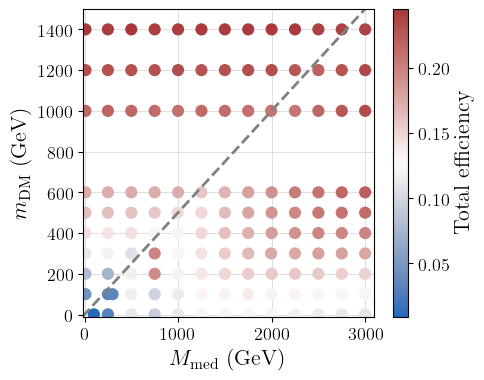

In [19]:
mmed = []
mdm = []
sumeffList = []

for f, sumeff in sumeff_dict.items():
    dm = int(f.split('_')[1])
    med = int(f.split('_')[2])

    mmed.append(med)
    mdm.append(dm)
    sumeffList.append(sumeff)


plt.scatter(x=mmed, y=mdm, c=sumeffList,
            cmap=plt.colormaps.get_cmap('vlag'), s=60)

plt.axline((1, 1), slope=1/2, linestyle='--', color='gray')

cbar=plt.colorbar(label=r'Total efficiency')
plt.xlabel(r'$M_{\rm med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{\rm DM}$ (GeV)')
plt.ylim(-10,1500)

plt.tight_layout()
# plt.savefig('./figures/comp-effs-spin1.png')

plt.show()

In [20]:
for f, rchi in redChis_dict.items():
    print(f,rchi)


dms_1000_1750 0.2511629046704396
dms_1000_1995 0.18256283586416666
dms_1000_2250 0.14660391889407678
dms_1000_2500 0.08615869732960114
dms_1000_2750 0.0529120881258909
dms_1000_3000 0.11677254437358227
dms_1200_10 0.06798572189127804
dms_1200_1000 0.1825315104559261
dms_1200_1250 0.12074563984955551
dms_1200_1500 0.1769639596068648
dms_1200_1750 0.21548848171007506
dms_1200_2000 0.28327140549002944
dms_1200_2250 0.054065006239277735
dms_1200_250 0.07636152528810919
dms_1200_2500 0.06557010049134428
dms_1200_2750 0.16063683616013277
dms_1200_3000 0.07981264160035811
dms_1200_500 0.2236487044499662
dms_1200_750 0.1530679977511888
dms_1400_10 0.1957882206096824
dms_1400_1000 0.12628185560367872
dms_1400_1250 0.11253610873937618
dms_1400_1500 0.1484914295086372
dms_1400_1750 0.1955300005395456
dms_1400_2000 0.10026738519312811
dms_1400_250 0.1145705183546309
dms_1400_500 0.054949892494584894
dms_1400_750 0.13703910092571542
dms_1_100 0.5807534534532351
dms_1_1000 0.3231023242011722
dms_1_1

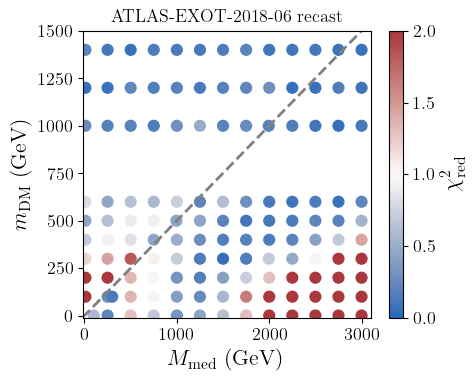

In [21]:
mmed = []
mdm = []
redChi = []

for f, rchi in redChis_dict.items():
    dm = int(f.split('_')[1])
    med = int(f.split('_')[2])

    mmed.append(med)
    mdm.append(dm)
    redChi.append(rchi)


plt.scatter(x=mmed, y=mdm, c=redChi, vmin=0, vmax=2,
            cmap=plt.colormaps.get_cmap('vlag'), s=60)

# plt.scatter(x=mmed, y=mdm, c=redChi, vmin=0., vmax=2.,
            # cmap=plt.colormaps.get_cmap('vlag'), s=60)

plt.axline((1, 1), slope=1/2, linestyle='--', color='gray')

cbar=plt.colorbar(label=r'$\chi^{2}_{\rm red}$')
plt.xlabel(r'$M_{\rm med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{\rm DM}$ (GeV)')
plt.ylim(-10,1500)
plt.title('ATLAS-EXOT-2018-06 recast')
plt.grid()

plt.tight_layout()
# plt.savefig('./figures/comp-effs-spin0.png')

plt.show()

In [19]:
mtuple = []
for i, m in enumerate(mmed):
    mtuple.append((mdm[i], m))

In [20]:
mtuple.sort()

In [21]:
for pair in mtuple:
    print(pair, end=', ')

(1, 100), (1, 250), (1, 500), (1, 750), (1, 1000), (1, 1250), (1, 1500), (1, 1750), (1, 2000), (1, 2250), (1, 2500), (1, 2750), (1, 3000), (100, 10), (100, 250), (100, 300), (100, 500), (100, 750), (100, 1000), (100, 1250), (100, 1500), (100, 1750), (100, 2000), (100, 2250), (100, 2500), (100, 2750), (100, 3000), (200, 10), (200, 250), (200, 500), (200, 750), (200, 1000), (200, 1250), (200, 1500), (200, 1750), (200, 2000), (200, 2250), (200, 2500), (200, 2750), (200, 3000), (300, 10), (300, 250), (300, 500), (300, 750), (300, 1000), (300, 1250), (300, 1500), (300, 1750), (300, 1995), (300, 2250), (300, 2500), (300, 2750), (300, 3000), (400, 10), (400, 250), (400, 500), (400, 750), (400, 1000), (400, 1250), (400, 1500), (400, 1750), (400, 2000), (400, 2250), (400, 2500), (400, 2750), (400, 3000), (500, 10), (500, 250), (500, 500), (500, 750), (500, 995), (500, 1250), (500, 1500), (500, 1750), (500, 2000), (500, 2250), (500, 2500), (500, 2750), (500, 3000), (600, 10), (600, 250), (600, 5

In [22]:
len(mtuple)

131

In [23]:
# merge dfs
dataComb = pd.merge(dataAx, dataVec, on=['mchi (GeV)', 'mMed (GeV)', 'Signal Region'], how='inner')

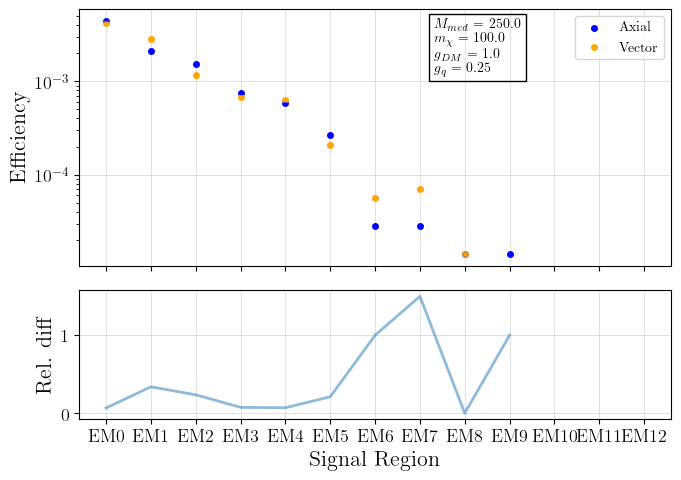

In [27]:
# plot eff diff
mxd = 100.
mmed = 250.
mFilter = (dataComb['mchi (GeV)'] == mxd) & (dataComb['mMed (GeV)'] == mmed)
x = dataComb[mFilter]['Signal Region']
y1 = dataComb[mFilter]['eff_a']
y1_err = dataComb[mFilter]['stat_a']
y2 = dataComb[mFilter]['eff_v']
y2_err = dataComb[mFilter]['stat_v']

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 0.25}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

ax[0].scatter(x, y1, label='Axial', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Vector', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, marker='.', linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [28]:
y1

936    0.004454
937    0.002101
938    0.001541
939    0.000742
940    0.000588
941    0.000266
942    0.000028
943    0.000028
944    0.000014
945    0.000014
946    0.000000
947    0.000000
948    0.000000
Name: eff_a, dtype: float64

In [29]:
y1_err

936    1.112232e-06
937    3.603228e-07
938    2.262788e-07
939    7.567781e-08
940    5.338617e-08
941    1.624371e-08
942    5.547531e-10
943    5.547531e-10
944    1.961349e-10
945    1.961349e-10
946    0.000000e+00
947    0.000000e+00
948    0.000000e+00
Name: stat_a, dtype: float64

In [100]:
dataVec_new = pd.read_pickle('../ma5_test_vector_match/ma5Results_test_vector_match.pcl')
dataAx_new = pd.read_pickle('../ma5_test_axial_match/ma5Results_test_axial_match.pcl')

In [101]:
# choose only EM
srs = [c for c in dataAx_new['Signal Region'] if not 'IM' in c]
dataAx_new = dataAx_new[dataAx_new['Signal Region'].isin(srs)]
dataVec_new = dataVec_new[dataVec_new['Signal Region'].isin(srs)]

In [102]:
dataAx_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,92.583641,92.606957,276.0927,dma_100_250,250.0,100.0,0.004637,1.075050e-04
14,EM1,46.987566,46.976765,276.0927,dma_100_250,250.0,100.0,0.002614,8.376366e-05
15,EM2,32.750442,32.743613,276.0927,dma_100_250,250.0,100.0,0.001511,7.091360e-05
16,EM3,39.267812,39.577214,276.0927,dma_100_250,250.0,100.0,0.000752,2.242561e-05
17,EM4,38.267204,38.869657,276.0927,dma_100_250,250.0,100.0,0.000685,3.217050e-05
18,EM5,33.391418,34.229562,276.0927,dma_100_250,250.0,100.0,0.000231,8.148441e-06
19,EM6,45.831637,48.560246,276.0927,dma_100_250,250.0,100.0,0.000088,7.951834e-06
20,EM7,62.045541,69.260956,276.0927,dma_100_250,250.0,100.0,0.000032,2.153017e-06
21,EM8,57.350123,61.106272,276.0927,dma_100_250,250.0,100.0,0.000016,1.291206e-06
22,EM9,60.781024,54.772489,276.0927,dma_100_250,250.0,100.0,0.000007,9.786407e-07


In [103]:
dataVec_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,91.969957,91.993122,640.3959,dmv_100_250,250.0,100.0,0.004669,1.066803e-04
14,EM1,45.125985,45.114188,640.3959,dmv_100_250,250.0,100.0,0.002720,8.103377e-05
15,EM2,38.095991,38.088048,640.3959,dmv_100_250,250.0,100.0,0.001296,4.385584e-05
16,EM3,38.417130,38.719829,640.3959,dmv_100_250,250.0,100.0,0.000769,3.516686e-05
17,EM4,38.689571,39.298673,640.3959,dmv_100_250,250.0,100.0,0.000677,3.252566e-05
18,EM5,37.073061,38.003616,640.3959,dmv_100_250,250.0,100.0,0.000208,7.665222e-06
19,EM6,41.243114,43.698531,640.3959,dmv_100_250,250.0,100.0,0.000098,1.100990e-05
20,EM7,33.094652,36.943303,640.3959,dmv_100_250,250.0,100.0,0.000059,2.126702e-05
21,EM8,47.141221,50.228738,640.3959,dmv_100_250,250.0,100.0,0.000019,3.679570e-06
22,EM9,63.947607,57.626047,640.3959,dmv_100_250,250.0,100.0,0.000007,7.500524e-07


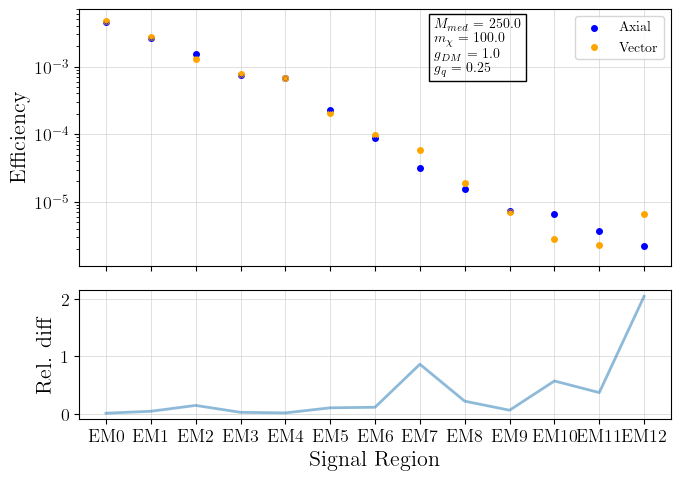

In [104]:
mmed = dataAx_new['mMed (GeV)'].tolist()[0]
mxd = dataAx_new['mchi (GeV)'].tolist()[0]

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 0.25}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

x = dataAx_new['Signal Region']
y1 = np.array(dataAx_new['Efficiency'])
y2 = np.array(dataVec_new['Efficiency'])
y1_err = np.array(dataAx_new['Efficiency_Err'])
y2_err = np.array(dataVec_new['Efficiency_Err'])

ax[0].scatter(x, y1, label='Axial', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Vector', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, marker='.', linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [107]:
(y1 - y2)**2

array([9.72086811e-10, 1.12237410e-08, 4.63971677e-08, 2.73951844e-10,
       7.03687103e-11, 5.42477806e-10, 9.47055833e-11, 7.44422703e-10,
       1.12681386e-11, 1.90167368e-13, 1.36867162e-11, 1.77646933e-12,
       2.01146142e-11])

In [106]:
(y1_err**2 + y2_err**2)

array([2.29380082e-08, 1.35828224e-08, 6.95207376e-09, 1.73961626e-09,
       2.09285995e-09, 1.25152728e-10, 1.84449538e-10, 4.56921746e-10,
       1.52064502e-11, 1.52031616e-12, 2.95945077e-12, 3.80287910e-12,
       1.83385355e-11])

In [109]:
np.array((y1 - y2)**2 / (y1_err**2 + y2_err**2)).sum()/(dof)

np.float64(1.7721399190168754)

In [84]:
dataScalar_new = pd.read_pickle('../ma5_test_spin0_scalar_match/ma5Results_test_scalar_match.pcl')
dataPseudo_new = pd.read_pickle('../ma5_test_spin0_pseudo_match/ma5Results_test_pseudo_match.pcl')

In [85]:
# choose only EM
srs = [c for c in dataScalar_new['Signal Region'] if not 'IM' in c]
dataScalar_new = dataScalar_new[dataScalar_new['Signal Region'].isin(srs)]
dataPseudo_new = dataPseudo_new[dataPseudo_new['Signal Region'].isin(srs)]

In [86]:
dataScalar_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,28.991585,28.998887,1.301264,dms_1_350,1,1.0,0.014791,5.031022e-04
14,EM1,12.852657,12.849702,1.301264,dms_1_350,1,1.0,0.009550,2.620176e-04
15,EM2,8.364061,8.362317,1.301264,dms_1_350,1,1.0,0.005901,2.334939e-04
16,EM3,9.662193,9.738324,1.301264,dms_1_350,1,1.0,0.003058,9.309664e-05
17,EM4,9.276808,9.422926,1.301264,dms_1_350,1,1.0,0.002820,1.033406e-04
18,EM5,9.162013,9.391982,1.301264,dms_1_350,1,1.0,0.000841,2.131130e-05
19,EM6,13.164819,13.948593,1.301264,dms_1_350,1,1.0,0.000306,9.839137e-06
20,EM7,15.101814,16.858038,1.301264,dms_1_350,1,1.0,0.000130,2.549294e-05
21,EM8,18.273888,19.470728,1.301264,dms_1_350,1,1.0,0.000049,2.893295e-06
22,EM9,24.233837,21.838192,1.301264,dms_1_350,1,1.0,0.000018,1.236870e-06


In [87]:
dataPseudo_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,30.290153,30.297781,4.465051,dmp_1_350,1,1.0,0.014164,4.223470e-04
14,EM1,13.164313,13.161287,4.465051,dmp_1_350,1,1.0,0.009326,2.373667e-04
15,EM2,8.825366,8.823525,4.465051,dmp_1_350,1,1.0,0.005593,2.586481e-04
16,EM3,10.071019,10.150371,4.465051,dmp_1_350,1,1.0,0.002935,9.717783e-05
17,EM4,10.280444,10.442292,4.465051,dmp_1_350,1,1.0,0.002545,6.485633e-05
18,EM5,10.295219,10.553635,4.465051,dmp_1_350,1,1.0,0.000749,2.112310e-05
19,EM6,14.369305,15.224789,4.465051,dmp_1_350,1,1.0,0.000280,8.961815e-06
20,EM7,20.028271,22.357404,4.465051,dmp_1_350,1,1.0,0.000098,3.594650e-06
21,EM8,24.511813,26.117216,4.465051,dmp_1_350,1,1.0,0.000036,1.811863e-06
22,EM9,26.434241,23.821073,4.465051,dmp_1_350,1,1.0,0.000017,1.910783e-06


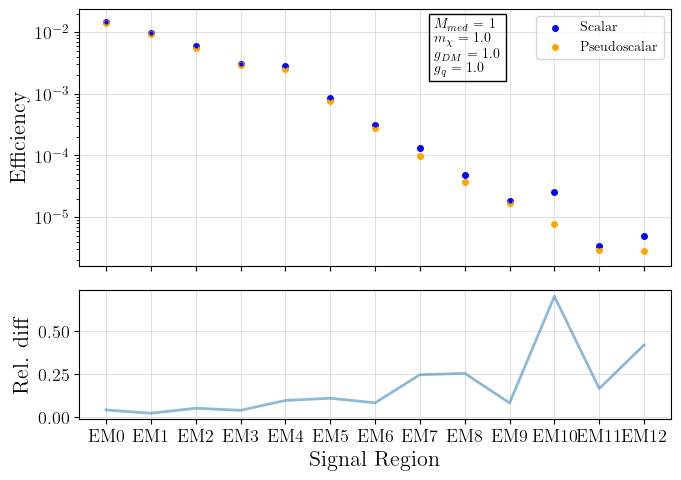

In [98]:
mmed = dataScalar_new['mMed (GeV)'].tolist()[0]
mxd = dataPseudo_new['mchi (GeV)'].tolist()[0]

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 1.0}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

x = dataScalar_new['Signal Region']
y1 = np.array(dataScalar_new['Efficiency'])
y2 = np.array(dataPseudo_new['Efficiency'])
y1_err = np.array(dataScalar_new['Efficiency_Err'])
y2_err = np.array(dataPseudo_new['Efficiency_Err'])

ax[0].scatter(x, y1, label='Scalar', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Pseudoscalar', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [89]:
np.abs(y1 - y2)/y1

array([0.0423474 , 0.02345732, 0.05221255, 0.04027256, 0.09758176,
       0.11047332, 0.08365225, 0.24697157, 0.25529742, 0.0829276 ,
       0.70238931, 0.16662399, 0.42014838])

In [90]:
(y1_err**2 + y2_err**2)

array([4.31488789e-07, 1.24996158e-07, 1.21418283e-07, 1.81105135e-08,
       1.48856271e-08, 9.00356913e-10, 1.77122743e-10, 6.62811423e-10,
       1.16540068e-11, 5.18094095e-12, 2.21119526e-10, 2.98627304e-13,
       6.11700043e-13])

In [99]:
np.array((y1 - y2)**2 / (y1_err**2 + y2_err**2)).sum()/(dof+1)

np.float64(3.555391307927692)

In [95]:
y1

array([1.47905786e-02, 9.54995230e-03, 5.90079526e-03, 3.05836714e-03,
       2.81997949e-03, 8.41477461e-04, 3.05992977e-04, 1.29749334e-04,
       4.88370093e-05, 1.84089989e-05, 2.55283201e-05, 3.45012366e-06,
       4.92763704e-06])

In [96]:
y1_err

array([5.03102207e-04, 2.62017597e-04, 2.33493949e-04, 9.30966353e-05,
       1.03340620e-04, 2.13113021e-05, 9.83913727e-06, 2.54929385e-05,
       2.89329529e-06, 1.23687033e-06, 1.48545702e-05, 3.75098867e-07,
       7.40438194e-07])

In [77]:
3.096063e+03/2.093267e+05

0.014790578554957395

In [81]:
(np.sqrt(1.109077e+04) / 2.093267e+05) * 0.014790578554957395

np.float64(7.441172715443876e-06)

In [82]:
(3.096063e+03/2.093267e+05) * (np.sqrt(1.109077e+04))/ 3.096063e+03

np.float64(0.0005031022071107421)

In [83]:
np.sqrt(1.109077e+04) / 2.093267e+05

np.float64(0.0005031022071107421)

In [110]:
2.789887908142857*1e3*139

387794.4192318572

In [111]:
1.301264e+00*1e3*139

180875.696

In [25]:
pd.read_pickle('../ma5Results_scalar_all.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.211444,0.002289
1,IM1,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.177396,0.001992
2,IM2,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.140901,0.001661
3,IM3,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.109688,0.001336
4,IM4,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.084982,0.001098
...,...,...,...,...,...,...,...,...,...
1035,EM8,2.655520,2.829443,4.888432e-02,dms_1_750,1,1.0,0.000337,0.000009
1036,EM9,2.919149,2.630575,4.888432e-02,dms_1_750,1,1.0,0.000154,0.000006
1037,EM10,5.581551,11.618738,4.888432e-02,dms_1_750,1,1.0,0.000072,0.000003
1038,EM11,5.841690,6.421301,4.888432e-02,dms_1_750,1,1.0,0.000038,0.000002


In [26]:
pd.read_pickle('../ma5Results_scalar_all_add.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,17.601130,17.608879,0.015506,dms_100_10,1,100.0,0.045542,0.000666
1,IM1,10.721137,10.733256,0.015506,dms_100_10,1,100.0,0.029423,0.000528
2,IM2,10.082023,10.109077,0.015506,dms_100_10,1,100.0,0.017691,0.000360
3,IM3,9.455234,9.513033,0.015506,dms_100_10,1,100.0,0.010400,0.000204
4,IM4,10.557332,10.673288,0.015506,dms_100_10,1,100.0,0.005942,0.000087
...,...,...,...,...,...,...,...,...,...
203,EM8,0.912056,0.981217,0.000021,dms_1_3000,1,1.0,0.000988,0.000031
204,EM9,0.721554,0.650229,0.000021,dms_1_3000,1,1.0,0.000627,0.000023
205,EM10,1.148467,2.500588,0.000021,dms_1_3000,1,1.0,0.000359,0.000014
206,EM11,0.988206,1.097167,0.000021,dms_1_3000,1,1.0,0.000228,0.000012
